# ***Random Forest***



## Step 1: Data preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# path to my dataset

dataset_path = "/content/drive/MyDrive/banana_dataset/dataset"

train_path = dataset_path + "/train"
val_path = dataset_path + "/val"
test_path = dataset_path + "/test"

In [ ]:
# counting the number of images in train/val/test for each class

import os

def count_images(folder_path):
    classes = ['overripe', 'ripe', 'unripe']
    counts = {}

    for cls in classes:
        class_path = os.path.join(folder_path, cls)
        counts[cls] = len(os.listdir(class_path))

    return counts

train_counts = count_images('/content/drive/MyDrive/banana_dataset/dataset/train')
val_counts   = count_images('/content/drive/MyDrive/banana_dataset/dataset/val')
test_counts  = count_images('/content/drive/MyDrive/banana_dataset/dataset/test')

train_counts, val_counts, test_counts

({'overripe': 4299, 'ripe': 1815, 'unripe': 620},
 {'overripe': 1326, 'ripe': 315, 'unripe': 184},
 {'overripe': 1010, 'ripe': 211, 'unripe': 180})

In [ ]:
import pandas as pd

df_data = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
})

df_data

,Train,Validation,Test
overripe,4299,1326,1010
ripe,1815,315,211
unripe,620,184,180


## Spet 2: Feature extraction
 The goal: to convert a photo of a banana into numbers that a Random Forest model can interpret
   1) read the image
   2) convert it to RGB
   3) calculate the mean colour values
   4) calculate the standard deviations
   5) calculate the brightness

In [ ]:
#2.1 including the necessary libraries

import cv2            # OpenCv - reads images
import numpy as np    # for working with arrays of numbers
import pandas as pd   # to create feature tables
import os             # for working with folders and files
from tqdm import tqdm # beautiful progress indicator, shows how many photos have already been processed

In [ ]:
#2.2 feature extraction function

def extract_features(img_path):
    img = cv2.imread(img_path)                      # 1. reading the image from the disc (in BGR format)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)     # 2. we translate BGR -> RGB, because OpenCV always reads photos in the wrong order, but ML uses RGB

    # 3. calculating the average values of the channels R, G, B
    mean_r = img[:, :, 0].mean() # average red color
    mean_g = img[:, :, 1].mean() # /-/-/ green color
    mean_b = img[:, :, 2].mean() # /-/-/ blue color

    # 4. calculating the standard deviations
    std_r = img[:, :, 0].std() # the spread of the red channel
    std_g = img[:, :, 1].std() # /-/-/ green channel
    std_b = img[:, :, 2].std() # /-/-/ blue channel

    # 5. overall image brightness
    brightness = img.mean()

    return [mean_r, mean_g, mean_b, std_r, std_g, std_b, brightness]

In [ ]:
#2.3 creating a function to process a folder (train, val, test)
# it turns the folder with photos -> into a table of numerical attributes

def create_dataset(folder_path, label):  # label - class number: 0 = unripe, 1 = ripe, 2 = overripe
    features = []                       # will keep the attributes of all images
    filenames = os.listdir(folder_path) # getting a list of all files in a folder

    for file in tqdm(filenames):
        img_path = os.path.join(folder_path, file) # the full path to the image
        feats = extract_features(img_path) # extracting features with the extract_features() function
        feats.append(label)               # adding a class label (0, 1, 2)
        features.append(feats)            # saving the entire list of features to a common set

    columns = ["mean_r", "mean_g", "mean_b", "std_r", "std_g", "std_b", "brightness", "label"]

    return pd.DataFrame(features, columns=columns)

In [ ]:
#2.4 creating feature tables for train/val/test

# ------------- TRAIN -------------
train_over = create_dataset(train_path + "/overripe", 0)   #class 0
train_ripe = create_dataset(train_path + "/ripe", 1)       #class 1
train_unripe = create_dataset(train_path + "/unripe", 2)   #class 2

print("------------- TRAIN -------------")
train_df = pd.concat([train_unripe, train_ripe, train_over], axis=0) # combining it into one table

# ------------- VALIDATION -------------
val_over = create_dataset(val_path + "/overripe", 0)   #class 0
val_ripe = create_dataset(val_path + "/ripe", 1)       #class 1
val_unripe = create_dataset(val_path + "/unripe", 2)   #class 2

print("------------- VALIDATION -------------")
val_df = pd.concat([val_over, val_ripe, val_unripe], axis=0)

# ------------- TEST -------------
test_over = create_dataset(test_path + "/overripe", 0)   #class 0
test_ripe = create_dataset(test_path + "/ripe", 1)       #class 1
test_unripe = create_dataset(test_path + "/unripe", 2)   #class 2

print("------------- TEST -------------")
test_df = pd.concat([test_over, test_ripe, test_unripe], axis=0)

100%|██████████| 620/620 [00:44<00:00, 14.06it/s]


------------- TRAIN -------------


100%|██████████| 184/184 [00:12<00:00, 14.34it/s]


------------- VALIDATION -------------


100%|██████████| 180/180 [00:12<00:00, 14.73it/s]

------------- TEST -------------


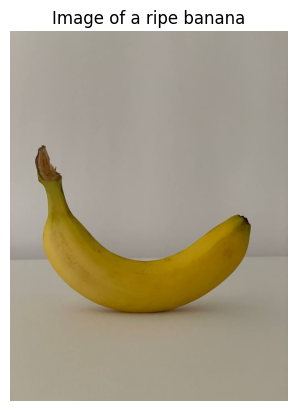


Extracted features:
mean_r: 161.91
mean_g: 152.10
mean_b: 129.38
std_r: 12.65
std_g: 18.60
std_b: 45.47
brightness: 147.79


In [ ]:
import matplotlib.pyplot as plt
import cv2

img_path = train_path + "/ripe/banana3_day1_07.jpg"

# showing the image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Image of a ripe banana")
plt.axis("off")
plt.show()

# feature extraction
features = extract_features(img_path)

columns = ["mean_r", "mean_g", "mean_b", "std_r", "std_g", "std_b", "brightness"]

print("\nExtracted features:")
for name, value in zip(columns, features):
    print(f"{name}: {value:.2f}")

In [ ]:
train_df.head()

,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness,label
0,159.183270,154.339373,128.923153,14.994341,17.982971,42.055813,147.481932,2
1,161.070889,156.482825,129.490517,17.953507,21.493327,48.385539,149.014744,2
2,162.538771,156.103531,126.509287,17.913409,20.836430,46.433702,148.383863,2
3,167.728083,161.070033,131.171902,19.286040,22.512596,47.931305,153.323340,2
4,167.695031,161.055604,131.186070,19.351226,22.584647,48.000302,153.312235,2


In [ ]:
val_df.head()

,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness,label
0,165.388444,155.527461,133.199556,15.393375,23.164855,46.888737,151.371820,0
1,168.802920,158.670251,138.442692,18.661865,26.168958,45.958309,155.305288,0
2,168.482113,158.921453,138.118057,20.130228,28.014449,46.836323,155.173874,0
3,170.584764,158.815412,140.332695,20.347405,29.052485,47.947072,156.577624,0
4,171.702225,159.712144,142.113590,20.303220,28.546257,46.506662,157.842653,0


In [ ]:
test_df.head()

,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness,label
0,97.171236,91.258704,76.868450,12.822230,17.646396,25.653289,88.432796,0
1,93.350140,87.633414,74.021985,16.127221,20.074590,25.149828,85.001846,0
2,91.668830,86.900505,70.757990,11.556496,16.729782,24.961908,83.109108,0
3,96.035006,89.496190,74.160391,13.171132,18.290727,26.922359,86.563862,0
4,95.116283,88.724324,73.541260,13.444115,18.303695,26.742883,85.793955,0


## STEP 3: Training the Random Forest model

In [ ]:
#3.1 Dividing the table into X and Y

# X = features(color, brightness, texture)
# y = classes(0, 1, 2)

# ------------- TRAIN -------------
X_train = train_df.drop("label", axis=1) #all columns except the label
y_train = train_df["label"]   # only the class label

# ------------- VALIDATION -------------
X_val = val_df.drop("label", axis=1)
y_val = val_df["label"]

# ------------- TEST -------------
X_test = test_df.drop("label", axis=1)
y_test = test_df["label"]

In [ ]:
X_train.shape, y_train.shape

((6734, 7), (6734,))

In [ ]:
X_val.shape, y_val.shape

((1825, 7), (1825,))

In [ ]:
X_test.shape, y_test.shape

((1401, 7), (1401,))

In [ ]:
#3.2 Training the Random Forest model

from sklearn.ensemble import RandomForestClassifier  #import the model

model = RandomForestClassifier(
    n_estimators=200,           #number of trees
    max_features='sqrt',        #how many features can be seen in each partition
    max_depth=None,               # WILL TEST IT LATER ON THE VAL SET
    class_weight='balanced',    # to correct the class imbalance
    random_state=42             #so that the results of the experiment are reproducible
)

model.fit(X_train, y_train)    # the model begins to learn

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

## STEP 4: Validation and configurationа

In [ ]:
#4.1 Validation of the base model on X_val, y_val

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

val_pred = model.predict(X_val) # model prediction on the validation set

# accuracy
val_accuracy = accuracy_score(y_val, val_pred) # shows the % of correct answers
print("Validation Accuracy:", val_accuracy)    # can not rely on it (my classes aren't balanced)

# precision (macro)
val_precision = precision_score(y_val, val_pred, average='macro') # macro - calculates metrics for each class and takes the average (this is for my non-uniform classes)
print("Macro Precision:", val_precision)

# recall (macro)
val_recall = recall_score(y_val, val_pred, average='macro')

# f1-score (macro)
val_f1 = f1_score(y_val, val_pred, average='macro')

# confusion matrix:
cm = confusion_matrix(y_val, val_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, val_pred))

Validation Accuracy: 0.8926027397260274
Macro Precision: 0.8427698925433885

Confusion Matrix:
[[1228   94    4]
 [  27  277   11]
 [  19   41  124]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1326
           1       0.67      0.88      0.76       315
           2       0.89      0.67      0.77       184

    accuracy                           0.89      1825
   macro avg       0.84      0.83      0.82      1825
weighted avg       0.91      0.89      0.90      1825



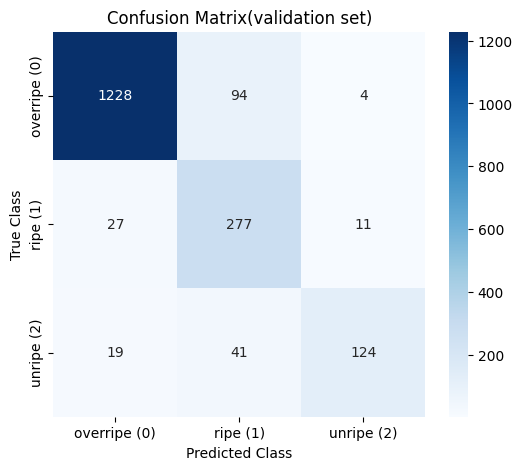

In [ ]:
# CONFUSION MATRIX VISUALIZATION (HEATMAP)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['overripe (0)', 'ripe (1)', 'unripe (2)'],
            yticklabels=['overripe (0)', 'ripe (1)', 'unripe (2)'])

plt.title("Confusion Matrix(validation set)")

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.show()

# Confusion matrix shows:
# 1) how many unripe models were confused with ripe ones
# 2) how many ripe models were confused with overripe ones
# 3) where the weak spots are

In [ ]:
#4.2 Selection of max_depth (experiment)
# we will compare how the validation accuracy changes at different tree depths

from sklearn.metrics import accuracy_score

depth_values = [5, 10, 15, 20, 25, None]
results = []

print("Testing different max_depth values:\n")

for depth in depth_values:
    model = RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        max_depth=depth,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)

    acc = accuracy_score(y_val, val_pred)

    results.append((depth, acc))
    print(f"max_depth={depth} -> validation accuracy = {acc:.4f}") #{acc:.4f} -> точность с 4 знаками после запятой

Testing different max_depth values:

max_depth=5 -> validation accuracy = 0.8159
max_depth=10 -> validation accuracy = 0.8778
max_depth=15 -> validation accuracy = 0.8921
max_depth=20 -> validation accuracy = 0.8921
max_depth=25 -> validation accuracy = 0.8915
max_depth=None -> validation accuracy = 0.8926


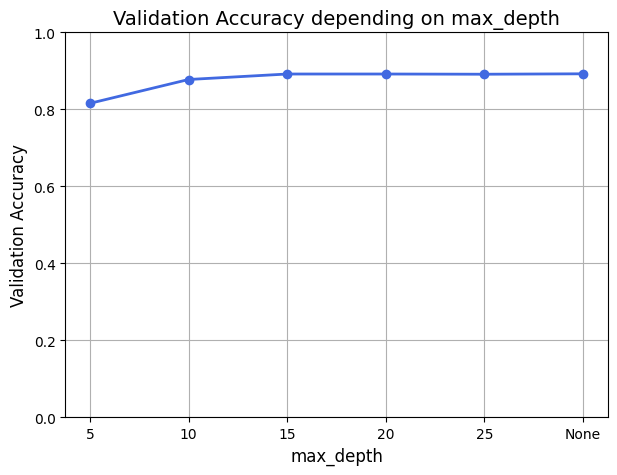

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# graph showing the relationship between accuracy and max_depth

# separating depth and accuracy for convenience
depth_list = [str(d) for d, _ in results]   # convert None to the string 'None'
accuracy_list = [acc for _, acc in results]

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(depth_list, accuracy_list, marker='o', linewidth=2, color='royalblue')

plt.title("Validation Accuracy depending on max_depth", fontsize=14)
plt.xlabel("max_depth", fontsize=12)
plt.ylabel("Validation Accuracy", fontsize=12)
plt.grid(True)

plt.ylim(0, 1)

plt.show()

In [ ]:
# 4.3 =========================== FINAL MODEL TRAINING (TRAIN) WITH THE MAX_DEPTH PARAMETER ===========================

from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',
    max_depth=25,              # the best parameter
    class_weight='balanced',
    random_state=42
)

final_model.fit(X_train, y_train)

print("The model was successfully trained with max_depth = 25")

The model was successfully trained with max_depth = 25


In [ ]:
# 4.4 =========================== FINAL MODEL VALIDATION ===========================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

val_pred_final = final_model.predict(X_val)

accuracy_final = accuracy_score(y_val, val_pred_final)
print("Final Validation ACCURACY:", accuracy_final)

print("\nFinal Classification report:")
print(classification_report(y_val, val_pred_final))

cm_final = confusion_matrix(y_val, val_pred_final)
print("\nFinal Confusion matrix:")
print(cm_final)



Final Validation ACCURACY: 0.8915068493150685

Final Classification report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1326
           1       0.67      0.88      0.76       315
           2       0.89      0.67      0.76       184

    accuracy                           0.89      1825
   macro avg       0.84      0.82      0.82      1825
weighted avg       0.91      0.89      0.89      1825


Final Confusion matrix:
[[1228   94    4]
 [  28  276   11]
 [  20   41  123]]


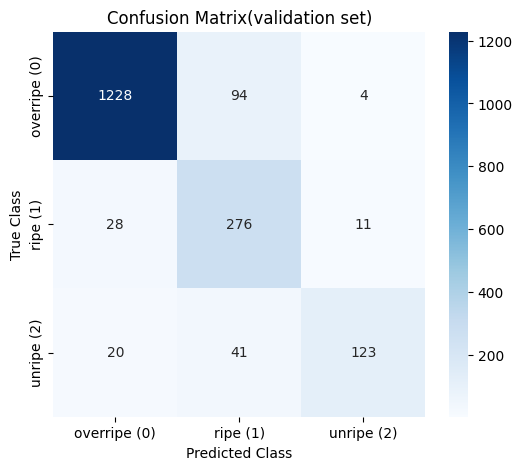

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['overripe (0)', 'ripe (1)', 'unripe (2)'],
            yticklabels=['overripe (0)', 'ripe (1)', 'unripe (2)'])

plt.title("Confusion Matrix(validation set)")

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.show()

### STEP 5: Final testing of the model on the test set

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

test_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_pred)
print("Final TEST accuracy:", test_accuracy)

print("\nFinal TEST classification report:")
print(classification_report(y_test, test_pred))

cm_test = confusion_matrix(y_test, test_pred)
print("\nFinal TEST confusion matrix:")
print(cm_test)


Final TEST accuracy: 0.9014989293361885

Final TEST classification report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1010
           1       0.68      0.88      0.76       211
           2       0.93      0.79      0.85       180

    accuracy                           0.90      1401
   macro avg       0.86      0.86      0.85      1401
weighted avg       0.91      0.90      0.90      1401


Final TEST confusion matrix:
[[936  72   2]
 [ 17 185   9]
 [ 22  16 142]]


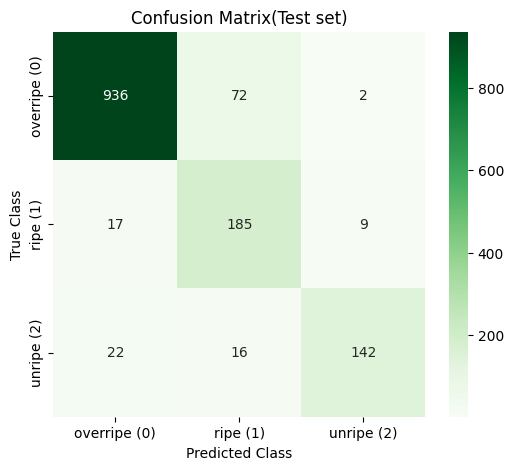

In [ ]:
# heatmap для Test set

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['overripe (0)', 'ripe (1)', 'unripe (2)'],
            yticklabels=['overripe (0)', 'ripe (1)', 'unripe (2)'])

plt.title("Confusion Matrix(Test set)")

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.show()

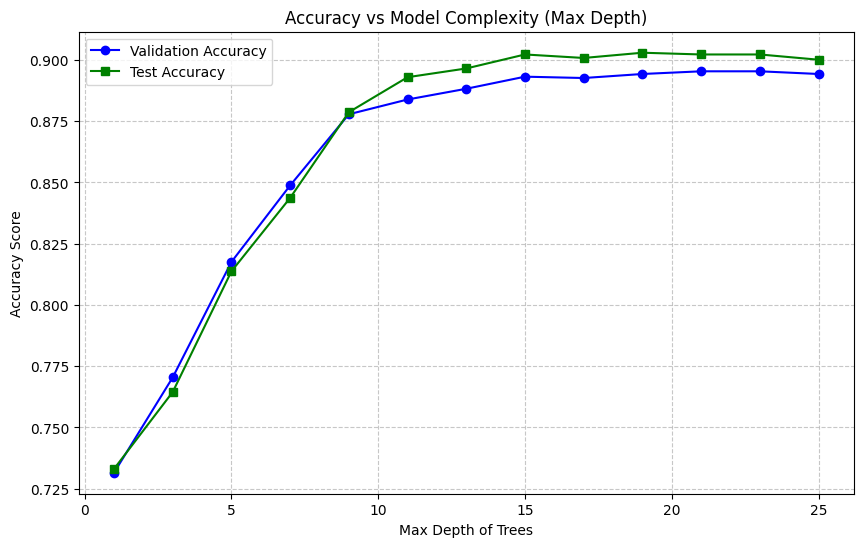

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Specify the range of values to be checked (e.g. tree depth)
depths = np.arange(1, 26, 2)
val_accuracies = []
test_accuracies = []

# 2. Training cycle for different hyperparameters
for d in depths:
    model = RandomForestClassifier(max_depth=d, n_estimators=100, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train) # Training on the train set

    # Calculating accuracy
    val_acc = accuracy_score(y_val, model.predict(X_val))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)

# 3. Visualization
plt.figure(figsize=(10, 6))
plt.plot(depths, val_accuracies, label='Validation Accuracy', marker='o', color='blue')
plt.plot(depths, test_accuracies, label='Test Accuracy', marker='s', color='green')

plt.title('Accuracy vs Model Complexity (Max Depth)')
plt.xlabel('Max Depth of Trees')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**ACCURACY: 90%**